In [ ]:
# 피터 린치의 GARP 전략 (교보증권 2021년 2월 24일)
# 사용지표: PEG(Price Earnings to Growth rate) 
# ; 밸류에이션 지표인 PER을 3년 평균 EPS 증가율로 나눈 값으로 해당 수치가 낮을수록 주가가 저평가돼 있거나 성장률이 높음을 의미

# 합리적인 가격의 성장주를 고르는 피터 린치의 GARP 전략: 
# 1) PEG < 1, 2) PER 50배 이하, 3) 과거 3년간 EPS 증가율 20% 이상, 
# 4) 부채비율 100% 이하, 5) 최근 3년간 매출 증가율 > 재고 증가율

In [1]:
import pandas as pd
import numpy as np

In [36]:
eps = pd.read_csv("eps.csv", index_col = 'Date', parse_dates = True)
per = pd.read_csv("per.csv", index_col = 'Date', parse_dates = True)

eps = eps.apply(pd.to_numeric, errors='coerce')
per = per.apply(pd.to_numeric, errors='coerce')

In [37]:
per_m = per.resample('ME').last()
eps_m = eps.resample('ME').last()

In [38]:
# 3년 PES 성장률
eps_growth_3y = eps_m / eps_m.shift(36) - 1

# PEG 계산
peg_df = per_m / eps_growth_3y

In [39]:
# 필터 적용하기
peg_df[(peg_df >= 1)] = pd.NA
peg_df[(per_m > 50)] = pd.NA
peg_df[(eps_growth_3y < 0.2)] = pd.NA

# 안정성 필터
peg_df[(eps_m <= 0)] = pd.NA
peg_df[(eps_growth_3y <= 0)] = pd.NA


In [40]:
# 팩터 계산 후 1개월 뒤에 투자
peg_signal = peg_df.shift(1)

In [41]:
#월 수익률 계싼
ac_df = pd.read_csv("수정주가.csv", index_col = 'Date', parse_dates = True)
price_m = ac_df.resample('ME').last()
monthly_return = price_m.pct_change(fill_method = None)

In [42]:
month_ends = ac_df.resample('ME').last().loc['2004-12-31':'2025-12-31'].index
peg_signal = peg_signal.reindex(month_ends)

portfolio_ret = pd.Series(dtype= float)
portfolio_ret[month_ends[0]] =0.0

In [49]:
for i in range(len(month_ends)-1):

    date = month_ends[i]
    next_date = month_ends[i+1]

    signal = peg_signal.loc[date].dropna()

    if len(signal) == 0:
        portfolio_ret.loc[next_date] = 0
        continue

    selected = signal.nsmallest(20).index

    ret = monthly_return.loc[next_date, selected].mean()

    portfolio_ret.loc[next_date] = ret
    
    monthly_return = monthly_return.reindex(month_ends)
    

In [50]:
portfolio_nav = (1+portfolio_ret).cumprod()
portfolio_nav

2004-12-31      1.000000
2005-01-31      1.000000
2005-02-28      1.000000
2005-03-31      1.000000
2005-04-30      1.000000
                 ...    
2025-08-31    101.779572
2025-09-30    120.253536
2025-10-31    131.581028
2025-11-30    136.517050
2025-12-31    142.825914
Length: 253, dtype: float64

<Axes: xlabel='Date'>

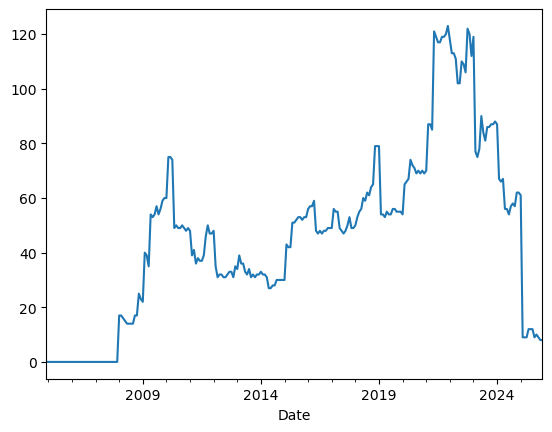

In [46]:
peg_signal.count(axis=1)
peg_signal.count(axis=1).plot()

In [47]:
eps.tail()

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,HD현대중공업,기아,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
